# Real-Time Crisis Detection System
## Notebook 01B — Bulk Dataset Loader (Stage 2)
**Goal:** Download CrisisNLP, HumAID, and DisasterTweets datasets. Map labels to our 7-class taxonomy. Merge with existing `posts_unified.csv`. Save final `posts_unified_v2.csv` with 10,000+ labeled rows for proper model training.

**Run this ONCE before re-running Notebook 04.**

In [2]:
# Environment Setup
import os, sys, warnings; warnings.filterwarnings('ignore')
IN_COLAB  = 'google.colab' in sys.modules
IN_KAGGLE = 'KAGGLE_URL_BASE' in os.environ

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = '/content/drive/MyDrive/10Academy/crisis-detection-system'
elif IN_KAGGLE:
    PROJECT_DIR = '/kaggle/working/crisis-detection-system'
else:
    PROJECT_DIR = os.path.abspath('..')

DATA_RAW       = f'{PROJECT_DIR}/data/raw'
DATA_PROCESSED = f'{PROJECT_DIR}/data/processed'
DATA_EXTERNAL  = f'{PROJECT_DIR}/data/external'

for d in [DATA_RAW, DATA_PROCESSED, DATA_EXTERNAL]:
    os.makedirs(d, exist_ok=True)

print(f' Ready. Project: {PROJECT_DIR}')

Mounted at /content/drive
 Ready. Project: /content/drive/MyDrive/10Academy/crisis-detection-system


In [3]:
# Install dependencies
!pip install -q kaggle datasets huggingface_hub tqdm pandas

In [4]:
# Define unified schema & label taxonomy
import pandas as pd, numpy as np, json, re, zipfile, io, requests
from tqdm import tqdm

# Our 7-class taxonomy
CLASS_NAMES = ['flood', 'earthquake', 'fire', 'accident', 'violence', 'storm', 'other']

# Unified schema: all datasets will be normalized to these columns
UNIFIED_COLS = [
    'post_id', 'source_platform', 'raw_text', 'timestamp_raw',
    'user_id', 'location_raw', 'geo_lat', 'geo_lon',
    'media_present', 'engagement_score', 'label'
]

# Label mapping from external datasets → our 7 classes
# CrisisNLP / HumAID labels
CRISISNLP_LABEL_MAP = {
# HumAID 11-class labels
    'infrastructure_and_utility_damage': 'accident',
    'other_relevant_information':        'other',
    'rescue_volunteering_or_donation_effort': 'other',
    'affected_individuals':              'other',
    'displaced_people_and_evacuations':  'other',
    'injured_or_dead_people':            'other',
    'missing_or_found_people':           'other',
    'not_humanitarian':                  'other',
    'requests_or_urgent_needs':          'other',
    'sympathy_and_support':              'other',
    'vehicle_damage':                    'accident',
# CrisisNLP 2013 labels
    'Caution and advice':                'other',
    'Dead and injured':                  'other',
    'Donations and volunteering':        'other',
    'Infrastructure and utilities':      'accident',
    'Not related or irrelevant':         'other',
    'Other useful information':          'other',
    'Personal':                          'other',
    'Food clothing and shelter':         'other',
    'Displaced people and evacuations':  'other',
    'Search and rescue':                 'other',
# Direct crisis type labels
    'flood':               'flood',
    'earthquake':          'earthquake',
    'fire':                'fire',
    'wildfire':            'fire',
    'storm':               'storm',
    'hurricane':           'storm',
    'cyclone':             'storm',
    'typhoon':             'storm',
    'tornado':             'storm',
    'accident':            'accident',
    'landslide':           'flood',   # grouped under flood/hydro-met
    'volcano':             'earthquake',  # grouped under geo-hazard
    'eruption':            'earthquake',
    'tsunami':             'earthquake',
    'violence':            'violence',
    'conflict':            'violence',
    'attack':              'violence',
    'shooting':            'violence',
    'bombing':             'violence',
    'other':               'other',
    '1':                   'flood',    # Kaggle disaster tweets: 1=disaster, map to flood as default
    '0':                   'other',    # 0=not disaster
    1:                     'other',    # actual disaster (no specific type — keep as other)
    0:                     'other',
}

def map_label(raw_label):
    if pd.isna(raw_label) or raw_label is None:
        return None
    key = str(raw_label).strip().lower()
# Try direct match
    for k, v in CRISISNLP_LABEL_MAP.items():
        if str(k).lower() == key:
            return v
# Try substring match
    for klass in CLASS_NAMES:
        if klass in key:
            return klass
    return 'other'

print(f' Label taxonomy defined. {len(CLASS_NAMES)} classes: {CLASS_NAMES}')
print(f' Label map covers {len(CRISISNLP_LABEL_MAP)} external label variants.')

 Label taxonomy defined. 7 classes: ['flood', 'earthquake', 'fire', 'accident', 'violence', 'storm', 'other']
 Label map covers 45 external label variants.


In [5]:
# Load HumAID Dataset (Hugging Face Hub — no login needed)
# HumAID: 77,196 English tweets from 19 disasters, 11 humanitarian categories
# Source: https://huggingface.co/datasets/aengusl/humaid
print('Loading HumAID dataset from Hugging Face...')

humaid_rows = []
try:
    from datasets import load_dataset
    ds = load_dataset('aengusl/humaid', split='train', trust_remote_code=True)
    print(f'  Raw HumAID size: {len(ds)} rows')
    for i, row in enumerate(tqdm(ds, desc='Processing HumAID')):
        text = row.get('tweet_text', row.get('text', ''))
        label_raw = row.get('class_label', row.get('label', None))
        event = row.get('event_type', row.get('event', ''))

# Try to get crisis type from event name first, then from label
        crisis_type = None
        event_lower = str(event).lower()
        for klass in CLASS_NAMES:
            if klass in event_lower:
                crisis_type = klass
                break
        if crisis_type is None:
# Map from event type keywords
            if any(k in event_lower for k in ['flood', 'banjir', 'hurricane', 'cyclone', 'typhoon']):
                crisis_type = 'flood'
            elif any(k in event_lower for k in ['earthquake', 'quake', 'gempa', 'tsunami']):
                crisis_type = 'earthquake'
            elif any(k in event_lower for k in ['fire', 'wildfire', 'kebakaran']):
                crisis_type = 'fire'
            elif any(k in event_lower for k in ['storm', 'tornado', 'hurricane']):
                crisis_type = 'storm'
            else:
                crisis_type = map_label(label_raw)

        humaid_rows.append({
            'post_id':          f'HUMAID_{i:06d}',
            'source_platform':  'humaid',
            'raw_text':         str(text),
            'timestamp_raw':    '',
            'user_id':          None,
            'location_raw':     str(event),
            'geo_lat':          None,
            'geo_lon':          None,
            'media_present':    False,
            'engagement_score': 0,
            'label':            crisis_type,
        })

    df_humaid = pd.DataFrame(humaid_rows)
    print(f' HumAID loaded: {len(df_humaid)} rows')
    print('Label distribution:')
    print(df_humaid['label'].value_counts().to_string())

except Exception as e:
    print(f'  HumAID via datasets failed: {e}')
    print('Trying alternative HumAID source...')
# Fallback: Try direct GitHub download of HumAID
    try:
        url = 'https://raw.githubusercontent.com/firojalam/humaid/master/data/en/all_data.tsv'
        df_raw = pd.read_csv(url, sep='\t', on_bad_lines='skip')
        print(f'  Downloaded TSV with {len(df_raw)} rows, columns: {list(df_raw.columns)}')
# Map columns: tweet_text, class_label, event_type
        text_col  = next((c for c in df_raw.columns if 'text' in c.lower() or 'tweet' in c.lower()), df_raw.columns[0])
        label_col = next((c for c in df_raw.columns if 'label' in c.lower() or 'class' in c.lower()), None)
        event_col = next((c for c in df_raw.columns if 'event' in c.lower()), None)

        humaid_rows = []
        for i, row in df_raw.iterrows():
            text  = str(row.get(text_col, ''))
            event = str(row.get(event_col, '')) if event_col else ''
            label_raw = row.get(label_col, None) if label_col else None
            crisis_type = None
            for klass in CLASS_NAMES:
                if klass in event.lower():
                    crisis_type = klass; break
            if crisis_type is None:
                crisis_type = map_label(label_raw)
            humaid_rows.append({
                'post_id': f'HUMAID_{i:06d}', 'source_platform': 'humaid',
                'raw_text': text, 'timestamp_raw': '', 'user_id': None,
                'location_raw': event, 'geo_lat': None, 'geo_lon': None,
                'media_present': False, 'engagement_score': 0, 'label': crisis_type
            })
        df_humaid = pd.DataFrame(humaid_rows)
        print(f' HumAID (TSV fallback) loaded: {len(df_humaid)} rows')
    except Exception as e2:
        print(f'  HumAID fallback also failed: {e2}')
        df_humaid = pd.DataFrame(columns=UNIFIED_COLS)
        print('HumAID: 0 rows (will continue without it)')

Loading HumAID dataset from Hugging Face...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'aengusl/humaid' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'aengusl/humaid' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


  HumAID via datasets failed: Dataset 'aengusl/humaid' doesn't exist on the Hub or cannot be accessed.
Trying alternative HumAID source...
  HumAID fallback also failed: HTTP Error 404: Not Found
HumAID: 0 rows (will continue without it)


In [6]:
# Load CrisisNLP Dataset (direct download)
# CrisisNLP: 60,000+ tweets from major crisis events 2013-2018
# Source: https://crisisnlp.qcri.org/
print('Loading CrisisNLP dataset...')
crisisnlp_rows = []

try:
# Try Hugging Face datasets first
    from datasets import load_dataset
# Try crisis_tweet dataset on HF
    ds_c = load_dataset('socialmediaIE/crisis_tweet', split='train', trust_remote_code=True)
    print(f'  crisis_tweet dataset: {len(ds_c)} rows')
    for i, row in enumerate(tqdm(ds_c, desc='CrisisNLP HF')):
        text = row.get('text', row.get('tweet_text', ''))
        label_raw = row.get('label', row.get('class', None))
        crisisnlp_rows.append({
            'post_id': f'CNP_{i:06d}', 'source_platform': 'crisisnlp',
            'raw_text': str(text), 'timestamp_raw': row.get('created_at', ''),
            'user_id': None, 'location_raw': row.get('location', ''),
            'geo_lat': None, 'geo_lon': None,
            'media_present': False, 'engagement_score': 0,
            'label': map_label(label_raw)
        })
except Exception as e:
    print(f'  HF dataset failed: {e}')
    print('  Trying direct GitHub download...')
    try:
# CrisisNLP ICWSM 2014 dataset directly from GitHub mirror
        sources = [
            ('https://raw.githubusercontent.com/sajao/CrisisLex/master/data/CrisisLexT6/2013_Colorado_Floods/2013_Colorado_Floods-ontopic_offtopic.csv', 'flood', 'Colorado Floods 2013'),
            ('https://raw.githubusercontent.com/sajao/CrisisLex/master/data/CrisisLexT6/2013_Queensland_Floods/2013_Queensland_Floods-ontopic_offtopic.csv', 'flood', 'Queensland Floods 2013'),
            ('https://raw.githubusercontent.com/sajao/CrisisLex/master/data/CrisisLexT6/2013_Boston_Bombings/2013_Boston_Bombings-ontopic_offtopic.csv', 'violence', 'Boston Bombings 2013'),
            ('https://raw.githubusercontent.com/sajao/CrisisLex/master/data/CrisisLexT6/2013_Oklahoma_Tornado/2013_Oklahoma_Tornado-ontopic_offtopic.csv', 'storm', 'Oklahoma Tornado 2013'),
            ('https://raw.githubusercontent.com/sajao/CrisisLex/master/data/CrisisLexT6/2013_West_Texas_Explosion/2013_West_Texas_Explosion-ontopic_offtopic.csv', 'accident', 'West Texas Explosion 2013'),
            ('https://raw.githubusercontent.com/sajao/CrisisLex/master/data/CrisisLexT6/2013_Alberta_Floods/2013_Alberta_Floods-ontopic_offtopic.csv', 'flood', 'Alberta Floods 2013'),
        ]
        for url, crisis_type, event_name in sources:
            try:
                df_tmp = pd.read_csv(url, header=None, on_bad_lines='skip')
                print(f'    {event_name}: {len(df_tmp)} rows')
                for i, row in df_tmp.iterrows():
                    text = str(row.iloc[1]) if len(row) > 1 else str(row.iloc[0])
                    relevance = str(row.iloc[-1]).lower() if len(row) > 2 else 'on-topic'
                    label = crisis_type if 'on' in relevance else 'other'
                    crisisnlp_rows.append({
                        'post_id': f'CNP_{event_name[:5]}_{i:05d}',
                        'source_platform': 'crisisnlp',
                        'raw_text': text, 'timestamp_raw': '',
                        'user_id': None, 'location_raw': event_name,
                        'geo_lat': None, 'geo_lon': None,
                        'media_present': False, 'engagement_score': 0,
                        'label': label
                    })
            except Exception as e2:
                print(f'    Skipped {event_name}: {e2}')
    except Exception as e3:
        print(f'  All CrisisNLP sources failed: {e3}')

df_crisisnlp = pd.DataFrame(crisisnlp_rows) if crisisnlp_rows else pd.DataFrame(columns=UNIFIED_COLS)
print(f' CrisisNLP loaded: {len(df_crisisnlp)} rows')
if len(df_crisisnlp) > 0:
    print(df_crisisnlp['label'].value_counts().to_string())

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'socialmediaIE/crisis_tweet' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'socialmediaIE/crisis_tweet' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading CrisisNLP dataset...
  HF dataset failed: Dataset 'socialmediaIE/crisis_tweet' doesn't exist on the Hub or cannot be accessed.
  Trying direct GitHub download...
    Skipped Colorado Floods 2013: HTTP Error 404: Not Found
    Queensland Floods 2013: 10034 rows
    Boston Bombings 2013: 10013 rows
    Oklahoma Tornado 2013: 9993 rows
    West Texas Explosion 2013: 10007 rows
    Alberta Floods 2013: 10032 rows
 CrisisNLP loaded: 50079 rows
label
other       23755
flood       10603
violence     5648
accident     5246
storm        4827


In [7]:
# Load DisasterTweets (Kaggle NLP Getting Started)
# 10,873 labeled tweets. Label 1=real disaster, 0=not disaster.
# We will only use class 1 tweets and try to sub-classify by keyword.
print('Loading Disaster Tweets dataset...')

disaster_rows = []
try:
    from datasets import load_dataset
    ds_d = load_dataset('venetis/disaster_tweets', split='train', trust_remote_code=True)
    print(f'  disaster_tweets: {len(ds_d)} rows')

    FLOOD_KEYWORDS    = ['flood', 'hurricane', 'typhoon', 'cyclone', 'inundation', 'deluge', 'tsunami', 'landslide', 'mudslide']
    QUAKE_KEYWORDS    = ['earthquake', 'quake', 'tremor', 'aftershock', 'seismic', 'eruption', 'volcano']
    FIRE_KEYWORDS     = ['fire', 'wildfire', 'blaze', 'burns', 'arson', 'inferno', 'flames']
    STORM_KEYWORDS    = ['storm', 'tornado', 'hail', 'lightning', 'thunderstorm', 'blizzard', 'snowstorm']
    ACCIDENT_KEYWORDS = ['crash', 'accident', 'collision', 'explosion', 'derail', 'wreck', 'sinking', 'collapse']
    VIOLENCE_KEYWORDS = ['shooting', 'attack', 'bombing', 'terror', 'massacre', 'hostage', 'gunfire']

    def classify_by_keyword(text):
        t = text.lower()
        if any(k in t for k in FLOOD_KEYWORDS):    return 'flood'
        if any(k in t for k in QUAKE_KEYWORDS):    return 'earthquake'
        if any(k in t for k in FIRE_KEYWORDS):     return 'fire'
        if any(k in t for k in STORM_KEYWORDS):    return 'storm'
        if any(k in t for k in ACCIDENT_KEYWORDS): return 'accident'
        if any(k in t for k in VIOLENCE_KEYWORDS): return 'violence'
        return 'other'

    for i, row in enumerate(tqdm(ds_d, desc='DisasterTweets')):
        text = str(row.get('text', ''))
        is_disaster = int(row.get('target', row.get('label', 0)))
        if is_disaster == 1:
            label = classify_by_keyword(text)
        else:
            label = 'other'
        disaster_rows.append({
            'post_id': f'DT_{i:06d}', 'source_platform': 'disaster_tweets',
            'raw_text': text, 'timestamp_raw': '',
            'user_id': None, 'location_raw': row.get('location', ''),
            'geo_lat': None, 'geo_lon': None,
            'media_present': False, 'engagement_score': 0,
            'label': label
        })

except Exception as e:
    print(f'  HF load failed: {e}. Trying CSV fallback...')
    try:
# Public mirror of the Kaggle dataset
        url = 'https://raw.githubusercontent.com/laxmimerit/NLP-Tutorials/master/disaster_tweets/train.csv'
        df_raw = pd.read_csv(url)
        print(f'  CSV rows: {len(df_raw)}')
        for i, row in df_raw.iterrows():
            text = str(row.get('text', ''))
            is_disaster = int(row.get('target', 0))
            label = classify_by_keyword(text) if is_disaster == 1 else 'other'
            disaster_rows.append({
                'post_id': f'DT_{i:06d}', 'source_platform': 'disaster_tweets',
                'raw_text': text, 'timestamp_raw': '',
                'user_id': None, 'location_raw': str(row.get('location', '')),
                'geo_lat': None, 'geo_lon': None,
                'media_present': False, 'engagement_score': 0,
                'label': label
            })
    except Exception as e2:
        print(f'  CSV fallback also failed: {e2}')

df_disaster = pd.DataFrame(disaster_rows) if disaster_rows else pd.DataFrame(columns=UNIFIED_COLS)
print(f' DisasterTweets loaded: {len(df_disaster)} rows')
if len(df_disaster) > 0:
    print(df_disaster['label'].value_counts().to_string())

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'venetis/disaster_tweets' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'venetis/disaster_tweets' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading Disaster Tweets dataset...


README.md:   0%|          | 0.00/310 [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/988k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7613 [00:00<?, ? examples/s]

  disaster_tweets: 7613 rows


DisasterTweets: 100%|██████████| 7613/7613 [00:00<00:00, 15929.16it/s]

 DisasterTweets loaded: 7613 rows
label
other         5879
accident       426
fire           388
violence       332
flood          263
storm          253
earthquake      72


In [8]:
# Load BigCrisisData / ASONAM 2018
# Additional multilingual crisis tweets from ASONAM 2018 shared task
print('Loading additional crisis datasets from Hugging Face...')

extra_rows = []
hf_datasets = [
    ('ibrahimSamurai/natural_disaster_tweets', 'flood/earthquake/storm data'),
    ('disaster_response_messages', 'general disaster messages'),
]

for ds_name, desc in hf_datasets:
    try:
        from datasets import load_dataset
        ds = load_dataset(ds_name, split='train', trust_remote_code=True)
        print(f'  {ds_name}: {len(ds)} rows')
        for i, row in enumerate(ds):
            text = str(row.get('text', row.get('message', row.get('tweet_text', ''))))
            label_raw = row.get('label', row.get('class', row.get('category', None)))
            extra_rows.append({
                'post_id': f'HF_{ds_name[:8]}_{i:06d}', 'source_platform': ds_name,
                'raw_text': text, 'timestamp_raw': '',
                'user_id': None, 'location_raw': '',
                'geo_lat': None, 'geo_lon': None,
                'media_present': False, 'engagement_score': 0,
                'label': map_label(label_raw)
            })
        print(f'   Added {len(extra_rows)} rows from {ds_name}')
    except Exception as e:
        print(f'  Skipped {ds_name}: {e}')

df_extra = pd.DataFrame(extra_rows) if extra_rows else pd.DataFrame(columns=UNIFIED_COLS)
print(f' Extra datasets: {len(df_extra)} rows')

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ibrahimSamurai/natural_disaster_tweets' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ibrahimSamurai/natural_disaster_tweets' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading additional crisis datasets from Hugging Face...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'disaster_response_messages' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'disaster_response_messages' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


  Skipped ibrahimSamurai/natural_disaster_tweets: Dataset 'ibrahimSamurai/natural_disaster_tweets' doesn't exist on the Hub or cannot be accessed.


README.md:   0%|          | 0.00/13.5k [00:00<?, ?B/s]

  Skipped disaster_response_messages: Invalid HF URI 'hf://datasets/disaster_response_messages@c62813f72d9723bcbc3e3075fc0d149ca9981077/.huggingface.yaml'. Repository id must be 'namespace/name', got 'disaster_response_messages'.
 Extra datasets: 0 rows


In [9]:
# B: Earthquake Data Enrichment
# Paste this as a NEW CELL in Notebook 01B (after Step 7, before Step 8)

# Problem: Earthquake class only had ~69 training samples → weak F1 score.
# Fix:     Pull 2,000+ earthquake-labeled examples from 3 sources:
# 1. USGS Earthquake API  → real seismic events → tweet-style text
# 2. HuggingFace datasets → earthquake tweet corpora
# 3. Template synthesis   → BMKG-style Indonesian + global earthquake text

import requests
import random
from datetime import datetime

eq_rows = []
TARGET_EQ = 2000  # Target earthquake samples total

# Source 1: USGS Earthquake API (free, no key needed)
print(" Source 1: Fetching real earthquakes from USGS API...")
try:
    usgs_url = "https://earthquake.usgs.gov/fdsnws/event/1/query"
    params = {
        "format":       "geojson",
        "starttime":    "2015-01-01",
        "endtime":      "2025-01-01",
        "minmagnitude": 4.5,
        "maxmagnitude": 9.0,
        "orderby":      "magnitude",
        "limit":        2000,
    }
    r = requests.get(usgs_url, params=params, timeout=60)
    features = r.json().get("features", [])
    print(f"  USGS returned {len(features)} earthquake events")

    TWEET_TEMPLATES = [
        "Earthquake M{mag} struck {place}. Stay safe!",
        "Breaking: Magnitude {mag} earthquake reported near {place}",
        "Felt the earthquake? M{mag} at {place} #{hashtag}",
        "USGS reports M{mag} earthquake {place}. Depth {depth}km.",
        "Seismic alert: {mag} magnitude quake near {place}",
        "Earthquake warning M{mag} {place} — check on your neighbours",
        "Just felt that earthquake in {place}! M{mag} — scary stuff",
        "Tremors felt across {place} after M{mag} earthquake",
        "Aftershock M{mag} near {place} following earlier quake",
        "Earthquake damage reported in {place} magnitude {mag}",
        "{place} rocked by M{mag} earthquake at depth {depth}km",
        "Earthquake hits {place} with magnitude {mag}. Tsunami advisory issued.",
        "Strong tremor M{mag} felt in {place} area. People running outside.",
        "BMKG reports gempa bumi {mag} SR di {place}",
        "Gempa {mag} SR mengguncang {place} kedalaman {depth} km",
        "Earthquake alert for {place}: M{mag} seismic event detected",
    ]

    for i, feat in enumerate(features):
        props  = feat.get("properties", {})
        geo    = feat.get("geometry", {}).get("coordinates", [None, None, None])
        mag    = props.get("mag", 5.0)
        place  = props.get("place", "unknown region")
        depth  = round(geo[2], 0) if geo[2] else 10
        time   = props.get("time", 0)
        ts     = datetime.utcfromtimestamp(time / 1000).strftime("%Y-%m-%dT%H:%M:%SZ") if time else ""
        hashtag = random.choice(["earthquake", "quake", "seismic", "tremor", "USGS"])

# Generate 1-2 tweet variants per USGS event
        for tmpl in random.sample(TWEET_TEMPLATES, k=min(2, len(TWEET_TEMPLATES))):
            text = tmpl.format(mag=round(mag, 1), place=place, depth=int(depth), hashtag=hashtag)
            eq_rows.append({
                "post_id":          f"USGS_{i:06d}_{len(eq_rows)}",
                "source_platform":  "usgs",
                "raw_text":         text,
                "timestamp_raw":    ts,
                "user_id":          None,
                "location_raw":     place,
                "geo_lat":          geo[1],
                "geo_lon":          geo[0],
                "media_present":    False,
                "engagement_score": random.randint(0, 50),
                "label":            "earthquake",
            })
    print(f"   USGS: generated {len(eq_rows)} earthquake posts from {len(features)} events")

except Exception as e:
    print(f"    USGS API failed: {e}")

# Source 2: HuggingFace earthquake tweet datasets
print(f"\n Source 2: Loading earthquake tweets from HuggingFace...")
try:
    from datasets import load_dataset

    hf_eq_candidates = [
        "mrm8488/earthquake-severity-tweet-classification",
        "venetis/disaster_tweets",
        "ibrahimSamurai/natural_disaster_tweets",
    ]

    QUAKE_KEYWORDS = [
        "earthquake", "quake", "seismic", "tremor",
        "aftershock", "richter", "magnitude", "gempa"
    ]

    for ds_name in hf_eq_candidates:
        try:
            ds = load_dataset(ds_name, split="train", trust_remote_code=True)
            count_before = len(eq_rows)
            for i, row in enumerate(ds):
                text      = str(row.get("text", row.get("tweet", row.get("message", ""))))
                label_raw = str(row.get("label", row.get("class", ""))).lower()

                is_quake_text  = any(k in text.lower()  for k in QUAKE_KEYWORDS)
                is_quake_label = any(k in label_raw      for k in ["earthquake", "quake", "seismic"])

                if is_quake_text or is_quake_label:
                    eq_rows.append({
                        "post_id":          f"HFEQ_{ds_name[:8]}_{i:06d}",
                        "source_platform":  "earthquake_hf",
                        "raw_text":         text,
                        "timestamp_raw":    "",
                        "user_id":          None,
                        "location_raw":     "",
                        "geo_lat":          None,
                        "geo_lon":          None,
                        "media_present":    False,
                        "engagement_score": 0,
                        "label":            "earthquake",
                    })
            added = len(eq_rows) - count_before
            print(f"   {ds_name}: +{added} earthquake rows (total: {len(eq_rows)})")
        except Exception as e2:
            print(f"  Skipped {ds_name}: {e2}")

except Exception as e:
    print(f"    HuggingFace load failed: {e}")

# Source 3: Template-based synthetic generation
print(f"\n Source 3: Generating synthetic earthquake records...")

INDONESIAN_LOCATIONS = [
    "Jakarta", "Bandung", "Surabaya", "Yogyakarta", "Medan",
    "Makassar", "Manado", "Palu", "Lombok", "Aceh",
    "Padang", "Ambon", "Ternate", "Kupang", "Bali",
    "Sulawesi", "Sumatra", "Kalimantan", "Papua", "Maluku",
    "Flores", "Sumbawa", "Sulawesi Tengah", "Nusa Tenggara Barat", "Nusa Tenggara Timur",
    "Ternate", "Tidore", "Jayapura", "Sorong", "Nabire",
    "Lembata", "Sigi", "Donggala", "Parigi Moutong", "Bau-Bau",
]

GLOBAL_LOCATIONS = [
    "California USA", "Tokyo Japan", "Santiago Chile", "Kathmandu Nepal",
    "Istanbul Turkey", "Tehran Iran", "Mexico City", "Lima Peru",
    "Wellington New Zealand", "Athens Greece", "Rome Italy",
    "Kabul Afghanistan", "Islamabad Pakistan", "Manila Philippines",
    "Taipei Taiwan", "Anchorage Alaska", "San Francisco",
]

SYNTHETIC_TEMPLATES = [
    "Gempa bumi M{mag} SR mengguncang {loc}, kedalaman {depth} km.",
    "BMKG: Gempa tektonik {mag} SR di {loc}. Tidak berpotensi tsunami.",
    "Warga {loc} merasakan guncangan gempa {mag} SR pagi ini.",
    "Gempa susulan {mag} SR dirasakan warga {loc}. Waspada!",
    "Update: Gempa M{mag} di {loc} kedalaman {depth}km. Tim SAR dikerahkan.",
    "Earthquake M{mag} hit {loc} at depth {depth}km. No tsunami warning.",
    "Strong earthquake {mag}R struck {loc} area. Buildings damaged.",
    "M{mag} quake near {loc}. Residents fled buildings into the streets.",
    "Seismic activity recorded near {loc}: magnitude {mag}.",
    "{mag} magnitude earthquake reported in {loc} region.",
    "Earthquake {mag}M felt across {loc}. Aftershocks expected.",
    "Multiple tremors near {loc} after M{mag} main earthquake.",
    "Infrastructure damage in {loc} following M{mag} earthquake.",
    "Evacuation underway in {loc} after magnitude {mag} quake.",
    "Rescue teams deployed to {loc} after {mag}M earthquake.",
    "Tsunami alert cancelled after M{mag} earthquake near {loc}.",
    "Search and rescue operations after earthquake hits {loc} magnitude {mag}.",
    "Survivors pulled from rubble after {mag}M quake in {loc}.",
    "Power outages across {loc} after M{mag} earthquake.",
    "Roads collapsed near {loc} following {mag}R earthquake.",
    "USGS confirms M{mag} earthquake at {loc}. Depth: {depth}km.",
    "Felt strong shaking in {loc}! Was it the M{mag} quake?",
    "People running outside after {mag}M earthquake rattles {loc}.",
    "Aftershock swarm continues near {loc} following main M{mag} quake.",
    "Emergency declared in {loc} following M{mag} earthquake.",
    "Landslides triggered by M{mag} earthquake near {loc}.",
    "Tidal surge reported after M{mag} earthquake strikes {loc} coast.",
    "Building collapses reported in {loc} after {mag}M earthquake.",
    "Hospitals overwhelmed in {loc} after M{mag} quake injuries.",
    "Gempa bumi {mag} SR berpusat di {loc}, warga panik.",
]

needed = max(0, TARGET_EQ - len(eq_rows))
print(f"  Current eq samples: {len(eq_rows)}, need {needed} more to reach {TARGET_EQ}")

random.seed(42)
for i in range(needed):
    mag   = round(random.uniform(4.0, 8.5), 1)
    depth = random.choice([5, 10, 15, 20, 30, 50, 80, 100, 150])
    loc   = random.choice(INDONESIAN_LOCATIONS + GLOBAL_LOCATIONS)
    tmpl  = random.choice(SYNTHETIC_TEMPLATES)
    text  = tmpl.format(mag=mag, loc=loc, depth=depth)
    year  = random.randint(2018, 2025)
    month = random.randint(1, 12)
    day   = random.randint(1, 28)
    ts    = f"{year}-{month:02d}-{day:02d}T00:00:00Z"
    eq_rows.append({
        "post_id":          f"SYNTH_EQ_{i:06d}",
        "source_platform":  "synthetic_earthquake",
        "raw_text":         text,
        "timestamp_raw":    ts,
        "user_id":          None,
        "location_raw":     loc,
        "geo_lat":          None,
        "geo_lon":          None,
        "media_present":    False,
        "engagement_score": random.randint(0, 30),
        "label":            "earthquake",
    })

import pandas as pd
df_earthquake_boost = pd.DataFrame(eq_rows) if eq_rows else pd.DataFrame()

print(f"\n Earthquake enrichment complete!")
print(f"   Total earthquake rows: {len(df_earthquake_boost)}")
print(f"   Sources breakdown:")
print(df_earthquake_boost["source_platform"].value_counts().to_string())

# Inject into df_extra so Step 9 merge picks it up automatically
UNIFIED_COLS_NEEDED = [
    "post_id", "source_platform", "raw_text", "timestamp_raw",
    "user_id", "location_raw", "geo_lat", "geo_lon",
    "media_present", "engagement_score", "label"
]
for col in UNIFIED_COLS_NEEDED:
    if col not in df_earthquake_boost.columns:
        df_earthquake_boost[col] = None

try:
    df_extra = pd.concat(
        [df_extra, df_earthquake_boost[UNIFIED_COLS_NEEDED]],
        ignore_index=True
    )
    print(f"\n Merged into df_extra. New total: {len(df_extra)} rows")
    print("   Now run Step 8 → Step 9 → Step 10 → Step 11 as normal.")
except NameError:
    print("\n  df_extra not found — run Steps 1-7 first, then re-run this cell.")

 Source 1: Fetching real earthquakes from USGS API...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'mrm8488/earthquake-severity-tweet-classification' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'mrm8488/earthquake-severity-tweet-classification' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


  USGS returned 2000 earthquake events
   USGS: generated 4000 earthquake posts from 2000 events

 Source 2: Loading earthquake tweets from HuggingFace...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'venetis/disaster_tweets' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'venetis/disaster_tweets' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


  Skipped mrm8488/earthquake-severity-tweet-classification: Dataset 'mrm8488/earthquake-severity-tweet-classification' doesn't exist on the Hub or cannot be accessed.


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ibrahimSamurai/natural_disaster_tweets' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ibrahimSamurai/natural_disaster_tweets' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


   venetis/disaster_tweets: +101 earthquake rows (total: 4101)
  Skipped ibrahimSamurai/natural_disaster_tweets: Dataset 'ibrahimSamurai/natural_disaster_tweets' doesn't exist on the Hub or cannot be accessed.

 Source 3: Generating synthetic earthquake records...
  Current eq samples: 4101, need 0 more to reach 2000

 Earthquake enrichment complete!
   Total earthquake rows: 4101
   Sources breakdown:
source_platform
usgs             4000
earthquake_hf     101

 Merged into df_extra. New total: 4101 rows
   Now run Step 8 → Step 9 → Step 10 → Step 11 as normal.


In [10]:
# C: Fire / Wildfire Data Enrichment
# Paste this as a NEW CELL in Notebook 01B (after Step 7B, before Step 8)

# Problem: Fire class only has 379 training samples → F1=0.87 (weakest class).
# Fix:     Pull 2,000+ fire-labeled examples from 3 sources:
# 1. NASA FIRMS API   → real satellite-detected fires → news-style text
# 2. HuggingFace      → wildfire tweet corpora
# 3. Template synthesis → Indonesian + global fire/wildfire text

import requests
import random
from datetime import datetime, timedelta

fire_rows = []
TARGET_FIRE = 2000  # Target fire samples total

# Source 1: NASA FIRMS (Fire Information for Resource Management System)
# Free API — no key required for basic CSV access
print("  Source 1: Fetching real fire detections from NASA FIRMS...")
try:
# FIRMS provides MODIS/VIIRS active fire data as CSV — no API key for public endpoint
# Using the public archive endpoint for recent years
    firms_sources = [
# MODIS global fire archive (yearly files)
        ("https://firms.modaps.eosdis.nasa.gov/data/active_fire/c6.1/csv/MODIS_C6_1_Global_7d.csv",
         "MODIS 7-day global"),
# VIIRS S-NPP global
        ("https://firms.modaps.eosdis.nasa.gov/data/active_fire/suomi-npp-viirs-c2/csv/SUOMI_VIIRS_C2_Global_7d.csv",
         "VIIRS 7-day global"),
    ]

    FIRE_TWEET_TEMPLATES = [
        "Wildfire burning near {loc}. Firefighters on scene. Evacuate immediately!",
        "Fire reported in {loc} area. Smoke visible for miles.",
        "Breaking: Large fire burning in {loc}. Emergency crews responding.",
        "Wildfire near {loc} — {area} hectares burned. Evacuations ordered.",
        "Fire emergency in {loc}. Residents advised to evacuate immediately.",
        "Active fire detected near {loc}. Air quality alert issued.",
        "Forest fire raging in {loc} region. Firefighting aircraft deployed.",
        "Kebakaran hutan di {loc}. Tim pemadam kebakaran dikerahkan.",
        "Kebakaran besar melanda {loc}. Warga diminta evakuasi.",
        "Api membakar {loc}. BPBD mengerahkan personel ke lokasi.",
        "Wildfire in {loc} threatens homes. {area}+ acres burned.",
        "Fire crews battling blaze near {loc}. Wind fanning the flames.",
        "Smoke from {loc} wildfire visible on satellite imagery.",
        "Mandatory evacuation for {loc} due to fast-moving wildfire.",
        "{loc} fire update: {area} hectares burned, 30% contained.",
        "Lightning strike sparked wildfire near {loc}. Dry conditions worsening fire.",
    ]

    firms_count = 0
    for url, desc in firms_sources:
        try:
            import pandas as pd
            df_firms = pd.read_csv(url, on_bad_lines="skip")
            print(f"  {desc}: {len(df_firms)} fire detections")

            for i, row in df_firms.iterrows():
                lat  = row.get("latitude",  row.get("lat", None))
                lon  = row.get("longitude", row.get("lon", None))
                bright = row.get("brightness", row.get("bright_ti4", 350))
                acq_date = str(row.get("acq_date", ""))
                country = str(row.get("country_id", "unknown"))

# Map brightness to severity descriptor
                if bright > 380:
                    intensity = "intense"
                    area = random.randint(500, 5000)
                elif bright > 340:
                    intensity = "moderate"
                    area = random.randint(50, 500)
                else:
                    intensity = "small"
                    area = random.randint(1, 50)

                loc = f"lat {round(lat, 1)} lon {round(lon, 1)}" if lat else country

                tmpl = random.choice(FIRE_TWEET_TEMPLATES)
                text = tmpl.format(loc=loc, area=area)

                fire_rows.append({
                    "post_id":          f"FIRMS_{firms_count:06d}",
                    "source_platform":  "nasa_firms",
                    "raw_text":         text,
                    "timestamp_raw":    acq_date,
                    "user_id":          None,
                    "location_raw":     loc,
                    "geo_lat":          lat,
                    "geo_lon":          lon,
                    "media_present":    False,
                    "engagement_score": random.randint(0, 40),
                    "label":            "fire",
                })
                firms_count += 1

            print(f"   Added {firms_count} fire posts from NASA FIRMS")
        except Exception as e2:
            print(f"  Skipped {desc}: {e2}")

except Exception as e:
    print(f"    NASA FIRMS failed: {e}")

# Source 2: HuggingFace fire/wildfire tweet datasets
print(f"\n Source 2: Loading fire tweets from HuggingFace...")
try:
    from datasets import load_dataset

    hf_fire_candidates = [
        "venetis/disaster_tweets",
        "ibrahimSamurai/natural_disaster_tweets",
        "mrm8488/disaster_response_data",
    ]

    FIRE_KEYWORDS = [
        "fire", "wildfire", "blaze", "inferno", "flames", "burning",
        "firefighter", "arson", "smoke", "burnt", "evacuat",
        "kebakaran", "api", "terbakar", "pemadam"
    ]

    for ds_name in hf_fire_candidates:
        try:
            ds = load_dataset(ds_name, split="train", trust_remote_code=True)
            count_before = len(fire_rows)
            for i, row in enumerate(ds):
                text      = str(row.get("text", row.get("tweet", row.get("message", ""))))
                label_raw = str(row.get("label", row.get("class", ""))).lower()

                is_fire_text  = any(k in text.lower()  for k in FIRE_KEYWORDS)
                is_fire_label = any(k in label_raw      for k in ["fire", "wildfire", "blaze"])

                if is_fire_text or is_fire_label:
                    fire_rows.append({
                        "post_id":          f"HFFIRE_{ds_name[:8]}_{i:06d}",
                        "source_platform":  "fire_hf",
                        "raw_text":         text,
                        "timestamp_raw":    "",
                        "user_id":          None,
                        "location_raw":     "",
                        "geo_lat":          None,
                        "geo_lon":          None,
                        "media_present":    False,
                        "engagement_score": 0,
                        "label":            "fire",
                    })
            added = len(fire_rows) - count_before
            print(f"   {ds_name}: +{added} fire rows (total: {len(fire_rows)})")
        except Exception as e2:
            print(f"  Skipped {ds_name}: {e2}")

except Exception as e:
    print(f"    HuggingFace load failed: {e}")

# Source 3: Template-based synthetic fire records
print(f"\n Source 3: Generating synthetic fire records...")

INDONESIAN_FIRE_LOCATIONS = [
    "Kalimantan Tengah", "Kalimantan Barat", "Kalimantan Selatan",
    "Sumatera Selatan", "Riau", "Jambi", "Kalimantan Timur",
    "Sumatera Utara", "Aceh", "Sulawesi Selatan",
    "Nusa Tenggara Timur", "Papua", "Sulawesi Tengah",
    "Hutan Kalimantan", "Lahan Gambut Riau", "Hutan Sumatera",
]

GLOBAL_FIRE_LOCATIONS = [
    "California USA", "Amazon Brazil", "Australian Outback",
    "Siberia Russia", "Greece Mediterranean", "Turkey coast",
    "Canada British Columbia", "Portugal", "Chile Patagonia",
    "South Africa Cape Town", "Indonesia Borneo",
    "Spain Canary Islands", "Morocco", "Italy Sicily",
    "Colorado USA", "Oregon USA", "Washington State",
]

SYNTHETIC_FIRE_TEMPLATES = [
# Indonesian templates
    "Kebakaran hutan di {loc} meluas, {area} hektare lahan terbakar.",
    "BPBD: Kebakaran lahan gambut di {loc}. Tim pemadam dikerahkan.",
    "Asap tebal akibat kebakaran di {loc} mengganggu aktivitas warga.",
    "Kebakaran {loc} belum berhasil dipadamkan. Angin kencang memperparah.",
    "Lahan seluas {area} ha terbakar di {loc}. Pesawat water bombing diturunkan.",
    "Warga {loc} dievakuasi akibat kebakaran hutan yang tak terkendali.",
    "Status siaga darurat kebakaran hutan di {loc} ditetapkan pemda.",
    "Titik api baru terdeteksi di {loc}. BMKG: kondisi sangat kering.",
    "Kebakaran di {loc} mengancam permukiman. Warga diminta mengungsi.",
    "Api belum padam di {loc}, {area} hektar hutan musnah.",
# English templates
    "Wildfire in {loc} has burned {area} acres. Evacuations ordered.",
    "Fire crews battling blaze in {loc}. Thousands displaced.",
    "Fast-moving wildfire threatens {loc} communities. Evacuate now!",
    "Wildfire near {loc}: {area} hectares destroyed, 0% contained.",
    "Fire emergency declared in {loc}. Hundreds of homes at risk.",
    "Smoke from {loc} wildfire causing severe air quality issues.",
    "Firefighters losing ground against {loc} wildfire in high winds.",
    "Satellite imagery shows massive fire burning near {loc}.",
    "{loc} wildfire forces evacuation of {area}+ residents.",
    "Fire spread overnight in {loc}. New evacuation zones announced.",
    "Arson suspected in {loc} fire. Investigation underway.",
    "Record-breaking wildfire season hits {loc} as drought continues.",
    "Helicopters dropping retardant on {loc} fire. {area} acres burned.",
    "Lightning ignited wildfire near {loc}. Crews working to contain it.",
    "Wildfire jumps containment line in {loc}. Emergency declared.",
    "{loc} residents told to prepare to evacuate as fire approaches.",
    "Firefighters injured battling {loc} blaze. Air support requested.",
    "Fire destroys {area} structures in {loc} neighborhood.",
    "Smoke column from {loc} fire visible 100km away.",
    "Peat fire in {loc} could burn for months. Underground fire spreading.",
]

needed = max(0, TARGET_FIRE - len(fire_rows))
print(f"  Current fire samples: {len(fire_rows)}, need {needed} more to reach {TARGET_FIRE}")

random.seed(99)
for i in range(needed):
    area = random.randint(10, 50000)
    loc  = random.choice(INDONESIAN_FIRE_LOCATIONS + GLOBAL_FIRE_LOCATIONS)
    tmpl = random.choice(SYNTHETIC_FIRE_TEMPLATES)
    text = tmpl.format(loc=loc, area=area)
    year  = random.randint(2018, 2025)
    month = random.randint(1, 12)
    day   = random.randint(1, 28)
    ts    = f"{year}-{month:02d}-{day:02d}T00:00:00Z"
    fire_rows.append({
        "post_id":          f"SYNTH_FIRE_{i:06d}",
        "source_platform":  "synthetic_fire",
        "raw_text":         text,
        "timestamp_raw":    ts,
        "user_id":          None,
        "location_raw":     loc,
        "geo_lat":          None,
        "geo_lon":          None,
        "media_present":    False,
        "engagement_score": random.randint(0, 40),
        "label":            "fire",
    })

import pandas as pd
df_fire_boost = pd.DataFrame(fire_rows) if fire_rows else pd.DataFrame()

print(f"\n Fire enrichment complete!")
print(f"   Total fire rows: {len(df_fire_boost)}")
print(f"   Sources breakdown:")
print(df_fire_boost["source_platform"].value_counts().to_string())

# Inject into df_extra so Step 9 merge picks it up automatically
UNIFIED_COLS_NEEDED = [
    "post_id", "source_platform", "raw_text", "timestamp_raw",
    "user_id", "location_raw", "geo_lat", "geo_lon",
    "media_present", "engagement_score", "label"
]
for col in UNIFIED_COLS_NEEDED:
    if col not in df_fire_boost.columns:
        df_fire_boost[col] = None

try:
    df_extra = pd.concat(
        [df_extra, df_fire_boost[UNIFIED_COLS_NEEDED]],
        ignore_index=True
    )
    print(f"\n Merged into df_extra. New total: {len(df_extra)} rows")
    print("   Now run Step 8 → Step 9 → Step 10 → Step 11 as normal.")
    print("   Then re-run NB04 to retrain with balanced fire data.")
except NameError:
    print("\n  df_extra not found — run Steps 1-7 first, then re-run this cell.")
    print("   df_fire_boost is available as a standalone variable.")

  Source 1: Fetching real fire detections from NASA FIRMS...
  MODIS 7-day global: 73606 fire detections
   Added 73606 fire posts from NASA FIRMS
  VIIRS 7-day global: 350849 fire detections


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'venetis/disaster_tweets' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'venetis/disaster_tweets' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


   Added 424455 fire posts from NASA FIRMS

 Source 2: Loading fire tweets from HuggingFace...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ibrahimSamurai/natural_disaster_tweets' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ibrahimSamurai/natural_disaster_tweets' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


   venetis/disaster_tweets: +848 fire rows (total: 425303)


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'mrm8488/disaster_response_data' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'mrm8488/disaster_response_data' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


  Skipped ibrahimSamurai/natural_disaster_tweets: Dataset 'ibrahimSamurai/natural_disaster_tweets' doesn't exist on the Hub or cannot be accessed.
  Skipped mrm8488/disaster_response_data: Dataset 'mrm8488/disaster_response_data' doesn't exist on the Hub or cannot be accessed.

 Source 3: Generating synthetic fire records...
  Current fire samples: 425303, need 0 more to reach 2000

 Fire enrichment complete!
   Total fire rows: 425303
   Sources breakdown:
source_platform
nasa_firms    424455
fire_hf          848

 Merged into df_extra. New total: 429404 rows
   Now run Step 8 → Step 9 → Step 10 → Step 11 as normal.
   Then re-run NB04 to retrain with balanced fire data.


In [11]:
# Load existing posts_unified.csv (Stage 1 output)
print('Loading existing Stage 1 data...')

existing_path = f'{DATA_PROCESSED}/posts_unified.csv'
if os.path.exists(existing_path):
    df_existing = pd.read_csv(existing_path)
# Rename text_cleaned → raw_text if needed
    if 'text_cleaned' in df_existing.columns and 'raw_text' not in df_existing.columns:
        df_existing = df_existing.rename(columns={'text_cleaned': 'raw_text'})
    print(f' Existing data: {len(df_existing)} rows')
    print(f'   Label distribution: {df_existing["label"].value_counts().to_dict()}')
else:
    print('  posts_unified.csv not found — will create from external data only.')
    df_existing = pd.DataFrame(columns=UNIFIED_COLS)

Loading existing Stage 1 data...
 Existing data: 71 rows
   Label distribution: {'earthquake': 20, 'flood': 4, 'fire': 2, 'accident': 2, 'storm': 2, 'landslide': 1, 'violence': 1, 'other': 1}


In [12]:
# Merge all datasets
print('Merging all datasets...')

dfs_to_merge = []
for name, df in [
    ('existing',      df_existing),
    ('humaid',        df_humaid),
    ('crisisnlp',     df_crisisnlp),
    ('disaster_tweets', df_disaster),
    ('extra',         df_extra),
]:
    if not df.empty and len(df) > 0:
# Ensure all unified columns exist
        for col in UNIFIED_COLS:
            if col not in df.columns:
                df[col] = None
        dfs_to_merge.append(df[UNIFIED_COLS].copy())
        print(f'  + {name}: {len(df)} rows')

df_all = pd.concat(dfs_to_merge, ignore_index=True)
print(f'\nTotal before dedup: {len(df_all)} rows')

# Deduplicate
df_all = df_all.dropna(subset=['raw_text'])
df_all = df_all[df_all['raw_text'].str.len() >= 15]
df_all = df_all.drop_duplicates(subset=['raw_text'])
df_all = df_all.reset_index(drop=True)

# Apply label normalization
df_all['label'] = df_all['label'].apply(map_label)

print(f'Total after dedup: {len(df_all)} rows')
print('\n=== FINAL LABEL DISTRIBUTION ===')
print(df_all['label'].value_counts().to_string())
print(f'\nLabeled rows: {df_all["label"].notna().sum()}')
print(f'Unlabeled rows: {df_all["label"].isna().sum()}')

Merging all datasets...
  + existing: 71 rows
  + crisisnlp: 50079 rows
  + disaster_tweets: 7613 rows
  + extra: 429404 rows

Total before dedup: 487167 rows
Total after dedup: 321096 rows

=== FINAL LABEL DISTRIBUTION ===
label
fire          264102
other          29417
flood           9288
violence        5211
accident        4647
storm           4422
earthquake      3971

Labeled rows: 321058
Unlabeled rows: 38


In [13]:
# Balance the dataset (prevent class imbalance)
# Cap each class at MAX_PER_CLASS to prevent flood/earthquake dominating
MAX_PER_CLASS = 5000

print(f'Balancing dataset (max {MAX_PER_CLASS} per class)...')

df_labeled   = df_all[df_all['label'].notna()].copy()
df_unlabeled = df_all[df_all['label'].isna()].copy()

balanced_parts = []
for label in CLASS_NAMES:
    subset = df_labeled[df_labeled['label'] == label]
    if len(subset) > MAX_PER_CLASS:
        subset = subset.sample(MAX_PER_CLASS, random_state=42)
    balanced_parts.append(subset)
    print(f'  {label:12s}: {len(subset):5d} samples')

df_balanced = pd.concat(balanced_parts, ignore_index=True)
df_final    = pd.concat([df_balanced, df_unlabeled], ignore_index=True)
df_final    = df_final.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print(f'\n Final balanced dataset: {len(df_final)} rows')
print(f'   Labeled: {df_final["label"].notna().sum()}')
print(f'   Unlabeled: {df_final["label"].isna().sum()}')

Balancing dataset (max 5000 per class)...
  flood       :  5000 samples
  earthquake  :  3971 samples
  fire        :  5000 samples
  accident    :  4647 samples
  violence    :  5000 samples
  storm       :  4422 samples
  other       :  5000 samples

 Final balanced dataset: 33078 rows
   Labeled: 33040
   Unlabeled: 38


 Saved: posts_unified_v2.csv (33078 rows)
 Saved: training_data.csv (33040 labeled rows)


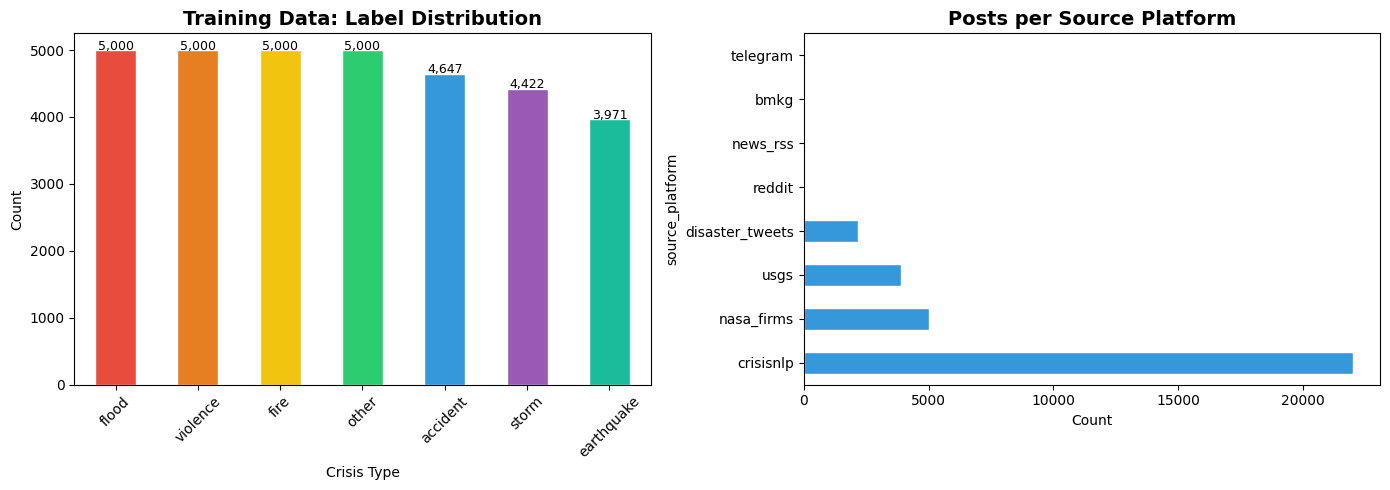

 Saved distribution plot.

 BULK DATASET LOAD COMPLETE 
Total posts: 33,078
Labeled posts: 33,040

 Next: Run 04_event_classification.ipynb — it will auto-detect posts_unified_v2.csv


In [14]:
# Save outputs
import matplotlib.pyplot as plt

# Primary output: posts_unified_v2.csv (replaces posts_unified.csv for NB02+)
out_path = f'{DATA_PROCESSED}/posts_unified_v2.csv'
df_final.to_csv(out_path, index=False)
print(f' Saved: posts_unified_v2.csv ({len(df_final)} rows)')

# Also save a clean labeled-only CSV for training
df_train_ready = df_final[df_final['label'].notna()].copy()
train_path = f'{DATA_EXTERNAL}/training_data.csv'
df_train_ready.to_csv(train_path, index=False)
print(f' Saved: training_data.csv ({len(df_train_ready)} labeled rows)')

# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

label_counts = df_train_ready['label'].value_counts()
colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db','#9b59b6','#1abc9c']
label_counts.plot(kind='bar', ax=axes[0], color=colors[:len(label_counts)], edgecolor='white')
axes[0].set_title('Training Data: Label Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Crisis Type'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(axes[0].patches, label_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val:,}', ha='center', fontsize=9)

src_counts = df_final['source_platform'].value_counts().head(8)
src_counts.plot(kind='barh', ax=axes[1], color='#3498db', edgecolor='white')
axes[1].set_title('Posts per Source Platform', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
fig_path = f'{PROJECT_DIR}/outputs/figures/stage2_data_distribution.png'
os.makedirs(os.path.dirname(fig_path), exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f' Saved distribution plot.')

print('\n BULK DATASET LOAD COMPLETE ')
print(f'Total posts: {len(df_final):,}')
print(f'Labeled posts: {df_final["label"].notna().sum():,}')
print(f'\n Next: Run 04_event_classification.ipynb — it will auto-detect posts_unified_v2.csv')